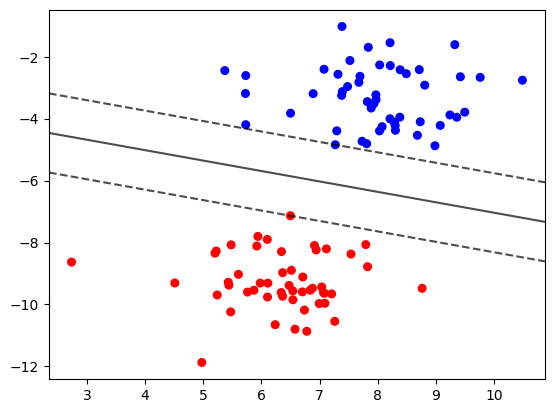

In [ ]:
from sklearn import datasets, svm
import matplotlib.pyplot as plt

X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=6)
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X, y)

# Plot decision boundary and margins
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

import numpy as np
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
Z = Z.reshape(XX.shape)

plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
            alpha=0.7, linestyles=['--', '-', '--'])
plt.show()


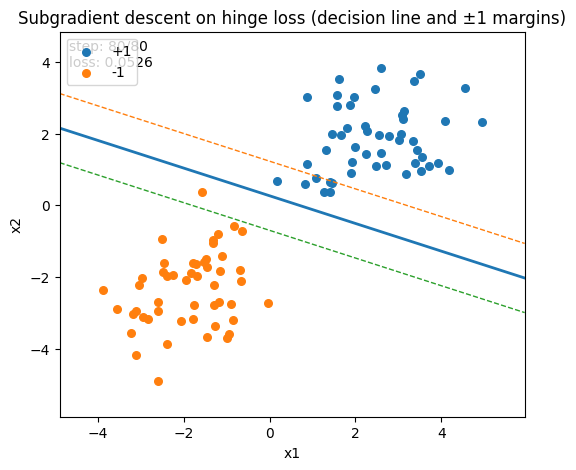

Saved 3D surface to hinge_loss_surface.html


In [ ]:
# svm_2d_animation_and_surface.py
# --------------------------------------------------------
# 2D margin classifier trained by subgradient descent on hinge loss:
#   J(w,b) = (1/N) * Σ max(0, 1 - y_i*(w1*x1_i + w2*x2_i + b)) + (λ/2)*(w1^2 + w2^2)
# Shows: decision boundary (f=0) and margins (f=±1) every step.
# Also exports a Plotly 3D surface of J(w1,w2) with b fixed.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path

# Optional: only needed if you want to save GIF/MP4
from matplotlib.animation import PillowWriter, FFMpegWriter

# OPTIONAL (if running in Jupyter): from IPython.display import HTML, display
# OPTIONAL (for 3D): pip install plotly
import plotly.graph_objects as go

# --------------------
# 1) Make a simple 2D dataset
# --------------------
np.random.seed(7)
n_per_class = 50

mean_pos = np.array([ 2.5,  2.0])
mean_neg = np.array([-2.0, -2.5])
cov = np.array([[1.0, 0.3],
                [0.3, 1.0]])

X_pos = np.random.multivariate_normal(mean_pos, cov, n_per_class)
X_neg = np.random.multivariate_normal(mean_neg, cov, n_per_class)

X = np.vstack([X_pos, X_neg])              # shape (N, 2)
y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])  # labels in {+1, -1}
N = X.shape[0]

# --------------------
# 2) Hinge loss + subgradient
# --------------------
lam   = 0.05  # L2 regularization (λ)
lr0   = 0.1   # initial learning rate
epochs = 80   # number of steps

w = np.random.randn(2) * 0.5  # start random
b = float(np.random.randn() * 0.5)

def hinge_loss_and_subgrad(w, b, X, y, lam):
    """
    Returns:
      loss (float), grad_w (2,), grad_b (scalar)
    """
    f = X @ w + b                 # scores
    margins = 1 - y * f
    loss_data = np.maximum(0.0, margins).mean()
    loss_reg  = 0.5 * lam * np.dot(w, w)
    loss = loss_data + loss_reg

    # subgradient: only points with margin>0 contribute
    mask = (margins > 0).astype(float)
    grad_w = -((y * mask) @ X) / X.shape[0] + lam * w
    grad_b = - (y * mask).sum() / X.shape[0]
    return loss, grad_w, grad_b

# Train and record trajectory
history = []
w_curr = w.copy()
b_curr = float(b)

for t in range(epochs):
    lr = lr0 / (1.0 + 0.03 * t)   # mild decay helps stabilization
    loss, gw, gb = hinge_loss_and_subgrad(w_curr, b_curr, X, y, lam)
    w_curr -= lr * gw
    b_curr -= lr * gb
    history.append((w_curr.copy(), float(b_curr), loss))

# --------------------
# 3) 2D Animation (matplotlib)
# --------------------
fig, ax = plt.subplots(figsize=(6,5))

ax.scatter(X[y==1, 0], X[y==1, 1], s=30, label="+1")
ax.scatter(X[y==-1, 0], X[y==-1, 1], s=30, label="-1")
ax.legend(loc="upper left")
ax.set_title("Subgradient descent on hinge loss (decision line and ±1 margins)")
ax.set_xlabel("x1"); ax.set_ylabel("x2")

x_min, x_max = X[:,0].min()-1.0, X[:,0].max()+1.0
y_min, y_max = X[:,1].min()-1.0, X[:,1].max()+1.0
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

line_decision, = ax.plot([], [], lw=2)              # f(x)=0
line_margin_p, = ax.plot([], [], lw=1, linestyle="--")  # f(x)=+1
line_margin_n, = ax.plot([], [], lw=1, linestyle="--")  # f(x)=-1
txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

xs = np.linspace(x_min, x_max, 200)

def line_as_xy(w, b, level, xs):
    """
    Return x,y arrays for the line w1*x + w2*y + b = level.
    Handles near-vertical cases.
    """
    w1, w2 = w
    eps = 1e-12
    if abs(w2) < 1e-9:
        # vertical line: x = (level - b)/w1
        x0 = (level - b) / (w1 + eps)
        return np.array([x0, x0]), np.array([y_min, y_max])
    ys = (level - w1*xs - b) / (w2 + eps)
    return xs, ys

def init():
    for ln in (line_decision, line_margin_p, line_margin_n):
        ln.set_data([], [])
    txt.set_text("")
    return line_decision, line_margin_p, line_margin_n, txt

def update(frame):
    w, b, loss = history[frame]
    x0, y0 = line_as_xy(w, b, 0.0, xs)
    x1, y1 = line_as_xy(w, b, +1.0, xs)
    x2, y2 = line_as_xy(w, b, -1.0, xs)
    line_decision.set_data(x0, y0)
    line_margin_p.set_data(x1, y1)
    line_margin_n.set_data(x2, y2)
    txt.set_text(f"step: {frame+1}/{epochs}\nloss: {loss:.4f}")
    return line_decision, line_margin_p, line_margin_n, txt

anim = FuncAnimation(fig, update, frames=len(history), init_func=init, blit=True, interval=120)

# --- Show inline if you're in Jupyter ---
# from IPython.display import HTML, display
# display(HTML(anim.to_jshtml()))

# --- Optional: save a GIF or MP4 (requires Pillow or ffmpeg) ---
# Path("outputs").mkdir(exist_ok=True)
anim.save("svm_margin_subgrad.gif", writer=PillowWriter(fps=10))
anim.save("svm_margin_subgrad.mp4", writer=FFMpegWriter(fps=10))
plt.show()

# --------------------
# 4) 3D Plotly error surface J(w1, w2) with b fixed
# --------------------
b_fixed = history[-1][1]  # fix at the final intercept (you can set 0.0 to explore)
w_final = history[-1][0]
span = 3.0
w1_vals = np.linspace(w_final[0]-span, w_final[0]+span, 90)
w2_vals = np.linspace(w_final[1]-span, w_final[1]+span, 90)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

def loss_surface(W1, W2, b, X, y, lam):
    # vectorized hinge loss over (w1,w2) grid
    x1 = X[:,0][:, None, None]
    x2 = X[:,1][:, None, None]
    yy = y[:, None, None]
    f = yy * (x1*W1[None, :, :] + x2*W2[None, :, :] + b)
    margins = 1 - f
    hinge = np.maximum(0.0, margins).mean(axis=0)
    reg = 0.5 * lam * (W1**2 + W2**2)
    return hinge + reg

Z = loss_surface(W1, W2, b_fixed, X, y, lam)

fig3d = go.Figure(data=[go.Surface(x=W1, y=W2, z=Z)])
fig3d.update_layout(
    title="Hinge-loss surface J(w1, w2) with b fixed",
    scene=dict(xaxis_title="w1", yaxis_title="w2", zaxis_title="J"),
    width=900, height=650
)

# Show in browser (Jupyter: fig3d.show(); script: write to HTML)
# fig3d.show()
fig3d.write_html("hinge_loss_surface.html", include_plotlyjs="cdn")
print("Saved 3D surface to hinge_loss_surface.html")


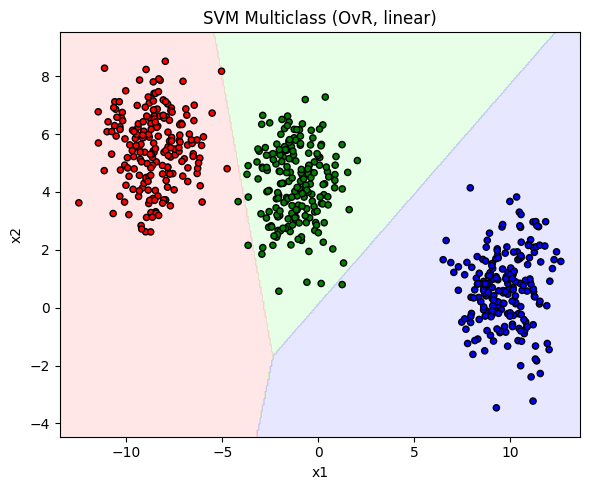

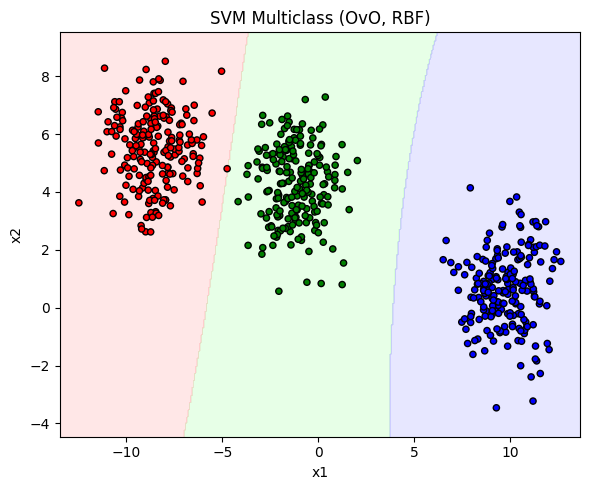

OvR conf matrix:
 [[199   1   0]
 [  2 197   1]
 [  0   0 200]]
OvO conf matrix:
 [[200   0   0]
 [  0 200   0]
 [  0   0 200]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# toy 2D, K=3
X, y = make_blobs(n_samples=600, centers=3, n_features=2, cluster_std=1.3, random_state=7)

def plot_regions(clf, X, y, title):
    x1min, x1max = X[:,0].min()-1, X[:,0].max()+1
    x2min, x2max = X[:,1].min()-1, X[:,1].max()+1
    xx1, xx2 = np.meshgrid(np.linspace(x1min, x1max, 400), np.linspace(x2min, x2max, 400))
    Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

    cmap = ListedColormap(['#FFBBBB','#BBFFBB','#BBBBFF'])
    plt.figure(figsize=(6,5))
    plt.contourf(xx1, xx2, Z, alpha=0.35, cmap=cmap)
    plt.scatter(X[:,0], X[:,1], c=y, s=20, edgecolor='k', cmap=ListedColormap(['r','g','b']))
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()

# ---- OvR (Linear) ----
ovr = LinearSVC(C=1.0, class_weight=None, dual="auto", random_state=0)
ovr.fit(X, y)
plot_regions(ovr, X, y, "SVM Multiclass (OvR, linear)")

# ---- OvO (RBF) ----
ovo = SVC(kernel="rbf", C=1.0, gamma="scale", decision_function_shape="ovo")
ovo.fit(X, y)
plot_regions(ovo, X, y, "SVM Multiclass (OvO, RBF)")

# Quick look at confusion matrices (self-check)
print("OvR conf matrix:\n", confusion_matrix(y, ovr.predict(X)))
print("OvO conf matrix:\n", confusion_matrix(y, ovo.predict(X)))


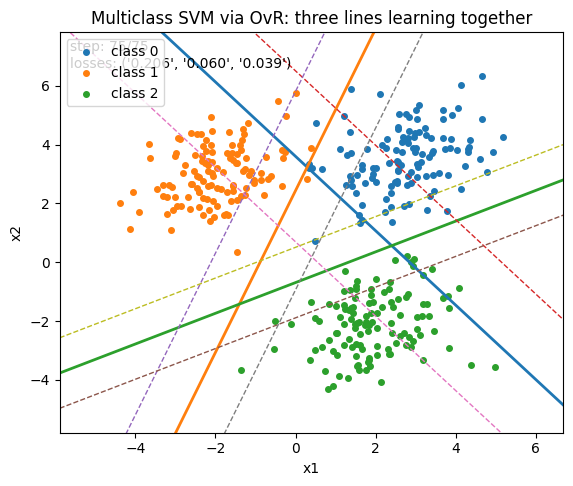

In [ ]:
# ovr_three_lines_animation.py
# ------------------------------------------------------------
# Trains 3 OvR hinge-loss classifiers (soft-margin SVM style)
# with subgradient descent, in parallel.
# Animates all three decision lines f_k(x)=0 and their ±1 margins.
#
# J_k(w,b) = (1/N) * sum_i max(0, 1 - y_i^(k)*(w·x_i + b)) + (λ/2)||w||^2
# where y_i^(k)=+1 if class==k else -1.  Prediction is argmax_k f_k(x).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --------------------
# 1) Toy 2D data with 3 classes
# --------------------
np.random.seed(12)
n = 120
means = np.array([[ 2.5,  3.5],
                  [-2.0,  3.0],
                  [ 2.0, -2.0]])
cov = np.array([[1.0, 0.25],
                [0.25, 1.0]])

X_list = [np.random.multivariate_normal(m, cov, n) for m in means]
X = np.vstack(X_list)                          # (3n, 2)
y = np.hstack([np.full(n, i) for i in range(3)])  # labels {0,1,2}
N = X.shape[0]

# --------------------
# 2) OvR hinge loss + subgradient descent (parallel for k=0,1,2)
# --------------------
lam   = 0.05        # L2 regularization
lr0   = 0.12        # initial learning rate
epochs = 75         # training steps

# parameters per class (w_k in R^2, b_k scalar)
W = np.random.randn(3, 2) * 0.5
B = np.random.randn(3) * 0.5

def hinge_loss_and_subgrad_ovr(wk, bk, X, y, k, lam):
    """One-vs-rest: yk = +1 if y==k else -1"""
    yk = np.where(y == k, 1.0, -1.0)
    f = X @ wk + bk
    margins = 1 - yk * f
    loss_data = np.maximum(0.0, margins).mean()
    loss_reg  = 0.5 * lam * (wk @ wk)
    loss = loss_data + loss_reg

    mask = (margins > 0).astype(float)            # only violators contribute
    grad_w = -((yk * mask) @ X) / X.shape[0] + lam * wk
    grad_b = - (yk * mask).sum() / X.shape[0]
    return loss, grad_w, grad_b

# Keep a history for animation
hist = [[] for _ in range(3)]
Wc = W.copy()
Bc = B.copy()

for t in range(epochs):
    lr = lr0 / (1.0 + 0.03 * t)   # mild decay
    for k in range(3):
        loss, gw, gb = hinge_loss_and_subgrad_ovr(Wc[k], Bc[k], X, y, k, lam)
        Wc[k] -= lr * gw
        Bc[k] -= lr * gb
        hist[k].append((Wc[k].copy(), float(Bc[k]), float(loss)))

# You can reduce the number of frames shown (downsample) to keep the animation lightweight:
frames_idx = np.linspace(0, epochs-1, 45, dtype=int)

# --------------------
# 3) Animation figure
# --------------------
fig, ax = plt.subplots(figsize=(6.5, 5.2))
for k in range(3):
    ax.scatter(X[y==k, 0], X[y==k, 1], s=16, label=f"class {k}")

ax.legend(loc="upper left")
ax.set_title("Multiclass SVM via OvR: three lines learning together")
ax.set_xlabel("x1"); ax.set_ylabel("x2")

x_min, x_max = X[:,0].min()-1.5, X[:,0].max()+1.5
y_min, y_max = X[:,1].min()-1.5, X[:,1].max()+1.5
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# For each class k: a decision line and two margin lines
dec_lines = [ax.plot([], [], lw=2)[0]                  for _ in range(3)]
pos_marg  = [ax.plot([], [], lw=1, linestyle="--")[0]  for _ in range(3)]
neg_marg  = [ax.plot([], [], lw=1, linestyle="--")[0]  for _ in range(3)]
txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

xs = np.linspace(x_min, x_max, 250)

def line_xy(w, b, level, xs):
    """Return (x, y) for the line w1*x + w2*y + b = level (handles vertical)."""
    w1, w2 = w
    eps = 1e-12
    if abs(w2) < 1e-9:
        x0 = (level - b) / (w1 + eps)
        return np.array([x0, x0]), np.array([y_min, y_max])
    ys = (level - w1*xs - b) / (w2 + eps)
    return xs, ys

def init():
    for k in range(3):
        dec_lines[k].set_data([], [])
        pos_marg[k].set_data([], [])
        neg_marg[k].set_data([], [])
    txt.set_text("")
    return (*dec_lines, *pos_marg, *neg_marg, txt)

def update(j):
    t = frames_idx[j]
    losses = []
    for k in range(3):
        w, b, loss = hist[k][t]
        x0, y0 = line_xy(w, b, 0.0, xs)
        x1, y1 = line_xy(w, b, +1.0, xs)
        x2, y2 = line_xy(w, b, -1.0, xs)
        dec_lines[k].set_data(x0, y0)
        pos_marg[k].set_data(x1, y1)
        neg_marg[k].set_data(x2, y2)
        losses.append(loss)
    txt.set_text(f"step: {t+1}/{epochs}\nlosses: {tuple(f'{L:.3f}' for L in losses)}")
    return (*dec_lines, *pos_marg, *neg_marg, txt)

anim = FuncAnimation(fig, update, frames=len(frames_idx), init_func=init, blit=True, interval=140)

# Show interactively in a notebook:
# from IPython.display import HTML, display
# display(HTML(anim.to_jshtml()))

# Optional: save as MP4/GIF (uncomment and ensure you have ffmpeg or pillow installed)
anim.save("ovr_multiclass_3lines.mp4", fps=12)  # requires ffmpeg
# from matplotlib.animation import PillowWriter
anim.save("ovr_multiclass_3lines.gif", writer=PillowWriter(fps=12))

plt.show()
